In [1]:
# Install core packages
!pip install -q numpy==2.0.0 scipy==1.14.1 networkx node2vec

# Install torch-geometric dependencies for torch 2.6.0 + CUDA 12.4
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install -q torch-spline-conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

# Install torch-geometric
!pip install -q torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 85.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 43.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 63.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.9 MB/s eta 0:00:00


In [2]:
''' This is when you don't want to go through google drive authentication '''

# import os
# import gdown
# import zipfile


# file_id = "1GW3RxcbGwn9bCXpCj1RST5-lUR18WI2d"
# url = f"https://drive.google.com/uc?id={file_id}"


# gdown.download(url, output="elliptic_bitcoin_dataset.zip", quiet=False)

# with zipfile.ZipFile("elliptic_bitcoin_dataset.zip", 'r') as zip_ref:
#     zip_ref.extractall()

" This is when you don't want to go through google drive authentication "

In [3]:
''' Dont run this cell'''

import zipfile
from google.colab import drive
drive.mount('/content/drive')


file_path = '/content/drive/MyDrive/elliptic_bitcoin_dataset.zip'

with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall()


Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import random
import torch
import torch_geometric

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community as community_louvain
import torch.nn as nn
import torch.nn.functional as F


from torch import Tensor
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from torch_geometric.data import Data
from scipy.stats import ttest_ind

print("Torch version:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Torch Geometric version:", torch_geometric.__version__)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=mpl.MatplotlibDeprecationWarning)

Torch version: 2.6.0+cu124
CUDA: 12.4
Torch Geometric version: 2.6.1


In [5]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


#Global Settings

In [6]:
RANDOM_STATE = 42
NUM_EPOCHS = 100

In [7]:
def set_seed_for_torch(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)      # For single-GPU.
        torch.cuda.manual_seed_all(seed)  # For multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def set_seed_for_numpy(seed):
    np.random.seed(seed)

def set_seed_for_random(seed):
    random.seed(seed)

In [8]:
set_seed_for_torch(RANDOM_STATE)
set_seed_for_numpy(RANDOM_STATE)
set_seed_for_random(RANDOM_STATE)

#Helper Methods

In [9]:
# ------------------------------------------- #
# Training, Evaluation and prediction methods
# ------------------------------------------- #

def train(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)

        correct = (pred[mask] == data.y[mask]).sum().item()
        accuracy = correct / mask.sum().item()

        y_true = data.y[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()

        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }

    return metrics

def predict(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out.argmax(dim=1)
    return pred

def predict_probabilities(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        probabilities = torch.exp(out)
    return probabilities

In [10]:
def train_gnn(num_epochs, data, model, optimizer, criterion):

    train_losses = []
    train_accuracies = []
    train_precisions = []
    train_recalls = []
    train_f1_scores = []

    val_accuracies = []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    # ----- #
    # Train #
    # ----- #

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out[data.train_mask],
                         data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # --- Calculate training metrics ---
        pred_train = out[data.train_mask].argmax(dim=1)
        correct_train = (pred_train == data.y[data.train_mask]).sum()
        train_acc = int(correct_train) / int(data.train_mask.sum())
        train_accuracies.append(train_acc)

        y_true_train = data.y[data.train_mask].cpu().numpy()
        y_pred_train = pred_train.cpu().numpy()

        train_prec = precision_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
        train_rec = recall_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
        train_f1 = f1_score(y_true_train, y_pred_train, average='weighted', zero_division=0)

        train_precisions.append(train_prec)
        train_recalls.append(train_rec)
        train_f1_scores.append(train_f1)
        train_losses.append(loss.item())

        # --- Validate and calculate validation metrics ---
        model.eval()
        with torch.no_grad():
            out = model(data)
            pred_val = out[data.val_mask].argmax(dim=1)
            correct_val = (pred_val == data.y[data.val_mask]).sum()
            val_acc = int(correct_val) / int(data.val_mask.sum())
            val_accuracies.append(val_acc)

            y_true_val = data.y[data.val_mask].cpu().numpy()
            y_pred_val = pred_val.cpu().numpy()

            val_prec = precision_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
            val_rec = recall_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
            val_f1 = f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0)

            val_precisions.append(val_prec)
            val_recalls.append(val_rec)
            val_f1_scores.append(val_f1)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Train - Acc: {train_acc:.4f} - Prec: {train_prec:.4f} - Rec: {train_rec:.4f} - F1: {train_f1:.4f}')
            print(f'                         Val   - Acc: {val_acc:.4f} - Prec: {val_prec:.4f} - Rec: {val_rec:.4f} - F1: {val_f1:.4f}')

    return {
        'train': {
            'losses': train_losses,
            'accuracies': train_accuracies,
            'precisions': train_precisions,
            'recalls': train_recalls,
            'f1_scores': train_f1_scores,
        },
        'val': {
            'accuracies': val_accuracies,
            'precisions': val_precisions,
            'recalls': val_recalls,
            'f1_scores': val_f1_scores,
        }
    }

In [11]:
def plot_train_val_test_metrics(train_val_metrics, test_metrics, num_epochs):
    plt.figure(figsize=(10, 6))

    # --- Accuracy ----
    plt.subplot(2, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['accuracies'], color='C0', linewidth=1.0, label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['accuracies'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['accuracy'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(fontsize=8)
    plt.title('Accuracy')

    # --- Precision ---
    plt.subplot(2, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['precisions'], color='C0', linewidth=1.0, label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['precisions'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['precision'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend(fontsize=8)
    plt.title('Precision')

    # --- Recall ---
    plt.subplot(2, 2, 3)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['recalls'], color='C0', linewidth=1.0, label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['recalls'], color='C1', linewidth=1.0, label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['recall'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend(fontsize=8)
    plt.title('Recall')

    # --- F1-Score ---
    plt.subplot(2, 2, 4)
    plt.plot(range(1, num_epochs + 1), train_val_metrics['train']['f1_scores'], linewidth=1.0, color='C0', label='Training')
    plt.plot(range(1, num_epochs + 1), train_val_metrics['val']['f1_scores'], linewidth=1.0, color='C1', label='Validation', linestyle=':')
    plt.axhline(y=test_metrics['f1_score'], color='C2', linewidth=0.5, linestyle='--', label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.legend(fontsize=8)
    plt.title('F1-Score')

    plt.tight_layout()
    plt.show()

# 📜 Overview

Let's start by getting an overview of the datasets.

In [12]:
elliptic_txs_features = pd.read_csv('/content/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)
elliptic_txs_classes = pd.read_csv('/content/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
elliptic_txs_edgelist = pd.read_csv('/content/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')


elliptic_txs_features.columns = ['txId'] + [f'V{i}' for i in range(1, 167)]

print(f"""Shapes
{4*' '}Features : {elliptic_txs_features.shape[0]:8,} (rows)  {elliptic_txs_features.shape[1]:4,} (cols)
{4*' '}Classes  : {elliptic_txs_classes.shape[0]:8,} (rows)  {elliptic_txs_classes.shape[1]:4,} (cols)
{4*' '}Edgelist : {elliptic_txs_edgelist.shape[0]:8,} (rows)  {elliptic_txs_edgelist.shape[1]:4,} (cols)
""")

Shapes
    Features :  203,769 (rows)   167 (cols)
    Classes  :  203,769 (rows)     2 (cols)
    Edgelist :  234,355 (rows)     2 (cols)



__Nodes & Edges__

- $|V| = 203,768$ (number of nodes in $G$)
- $|E| = 234,355$ (number of edges in $G$)

In [13]:
elliptic_txs_features.head(3)  # Dataset containing the node features.

,txId,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792


In [14]:
elliptic_txs_classes.head(3)  # Dataset containing the classes of the node.

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown


In [15]:
elliptic_txs_edgelist.head(3)  # Dataset containing the edges.

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870


Let's get an overview on the distribution of the `class`es.

In [16]:
elliptic_txs_classes['class_mapped'] = elliptic_txs_classes['class'].replace({'1': 'illicit', '2': 'licit'})

percentage_distribution = round(100 * elliptic_txs_classes['class_mapped'].value_counts(normalize=True), 2)
class_counts = elliptic_txs_classes['class_mapped'].value_counts()

emoji_mapping = {'licit': '✅', 'illicit': '❌', 'unknown': '🤷'}
elliptic_txs_classes['emoji'] = elliptic_txs_classes['class_mapped'].map(emoji_mapping)

classes_df = pd.DataFrame({
    'Class Mapped': elliptic_txs_classes['class_mapped'].unique(),
    'Class Raw': elliptic_txs_classes['class'].unique(),
    'Counts': class_counts.values,
    'Percentage': percentage_distribution.values,
    'Emoji': [emoji_mapping[class_label] for class_label in elliptic_txs_classes['class_mapped'].unique()]
})
classes_df

,Class Mapped,Class Raw,Counts,Percentage,Emoji
0,unknown,unknown,157205,77.15,🤷
1,licit,2,42019,20.62,✅
2,illicit,1,4545,2.23,❌


- 77.15% of all classes are `unknown`
- 20.62% of all classes are `licit` (2)
- 2.23% of all classes are `illicit` (1)

In [17]:
num_nodes = elliptic_txs_features.shape[0]
num_edges = elliptic_txs_edgelist.shape[0]

print(f"Number of nodes: {num_nodes:,}")
print(f"Number of edges: {num_edges:,}")

Number of nodes: 203,769
Number of edges: 234,355


In [18]:
# Create graph from the edgelist.
G = nx.from_pandas_edgelist(elliptic_txs_edgelist, 'txId1', 'txId2')

In [19]:
# Sampling for easier analysis...for now.
classes_sampled = elliptic_txs_classes.groupby('class_mapped').sample(frac=0.05, random_state=RANDOM_STATE)
txIds_sampled = classes_sampled['txId']

# Filter elliptic_txs_edgelist based on the sampled txIds
edgelist_sampled = elliptic_txs_edgelist[
    elliptic_txs_edgelist['txId1'].isin(txIds_sampled) | elliptic_txs_edgelist['txId2'].isin(txIds_sampled)
]

# Filter elliptic_txs_features based on the sampled txIds
features_sampled = elliptic_txs_features[elliptic_txs_features['txId'].isin(txIds_sampled)]

print(f"Sampled Classes:\n{classes_sampled['class_mapped'].value_counts()}\n")
print(f"Sampled Edgelist: {edgelist_sampled.shape[0]:,}")
print(f"Sampled Features: {features_sampled.shape[0]:,}")

Sampled Classes:
class_mapped
unknown    7860
licit      2101
illicit     227
Name: count, dtype: int64

Sampled Edgelist: 23,051
Sampled Features: 10,188


# 🔍 Exploratory Data Analysis (EDA)

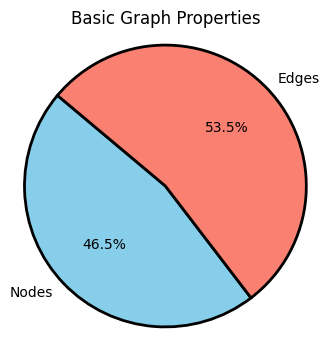

In [20]:
plt.figure(figsize=(4, 4))
sizes = [num_nodes, num_edges]
labels = ['Nodes', 'Edges']
colors = ['skyblue', 'salmon']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
        wedgeprops = {'edgecolor' : 'black',
                      'linewidth': 2,
                      'antialiased': True})
plt.title('Basic Graph Properties')
plt.axis('equal')
plt.show()

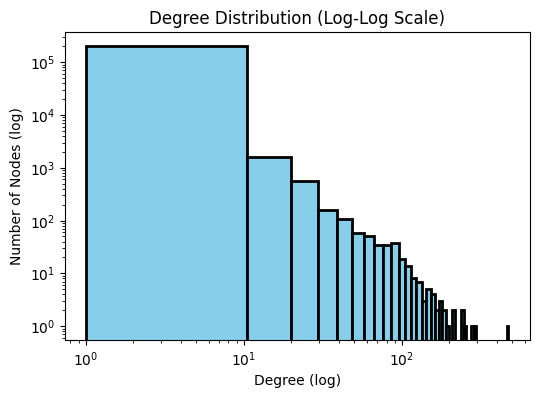

In [21]:
# --- Degree Distribution (Log-Log Scale) ---
plt.figure(figsize=(6, 4))
degrees = [G.degree(n) for n in G.nodes()]
plt.hist(degrees, bins=50, log=True, color='skyblue', edgecolor='black', linewidth=2.0)
plt.xscale('log')
plt.yscale('log')
plt.title('Degree Distribution (Log-Log Scale)')
plt.xlabel('Degree (log)')
plt.ylabel('Number of Nodes (log)')
plt.show()

## 📊 Basic Statistics

Number of nodes: 10,188
Number of edges: 23,051


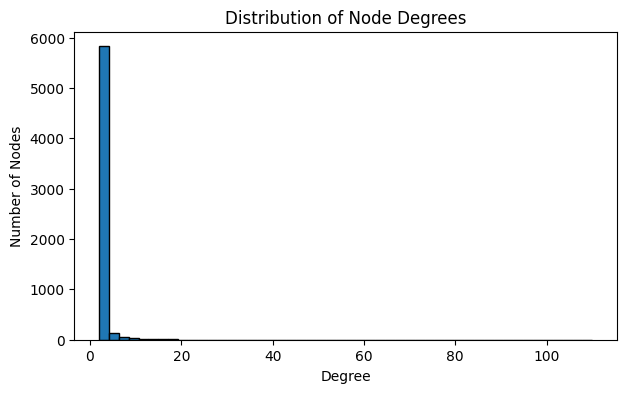

In [22]:
# Number of nodes and edges
num_nodes = features_sampled.shape[0]
num_edges = edgelist_sampled.shape[0]

print(f"Number of nodes: {num_nodes:,}")
print(f"Number of edges: {num_edges:,}")

# Distribution of node degrees
plt.figure(figsize=(7, 4))

node_degrees = edgelist_sampled['txId1'].value_counts() + edgelist_sampled['txId2'].value_counts()
node_degrees.hist(bins=50, edgecolor='black')
plt.title('Distribution of Node Degrees')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.grid(False)
plt.show()

## 🔗 Graph Connectivity

In [23]:
# Create graph from the edgelist.
G = nx.from_pandas_edgelist(edgelist_sampled, 'txId1', 'txId2')

Number of connected components: 7297
Giant component - Number of nodes: 400
Giant component - Number of edges: 431


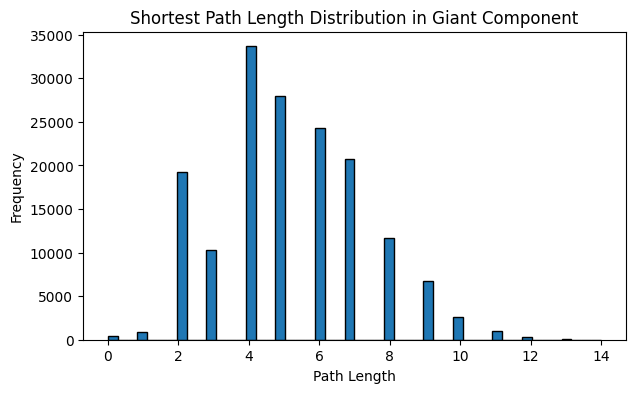

In [24]:
# --- Connected components ---
num_connected_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_connected_components}")

# --- Giant component analysis ---
giant_component = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component)

print(f"Giant component - Number of nodes: {G_giant.number_of_nodes():,}")
print(f"Giant component - Number of edges: {G_giant.number_of_edges():,}")


# --------------------------------------------------------- #
# Shortest paths length distribution in the giant component #
# --------------------------------------------------------- #
path_lengths = dict(nx.shortest_path_length(G_giant))
path_lengths_values = [length for target_lengths in path_lengths.values() for length in target_lengths.values()]

plt.figure(figsize=(7, 4))
plt.hist(path_lengths_values, bins=50, edgecolor='black')
plt.title('Shortest Path Length Distribution in Giant Component')
plt.xlabel('Path Length')
plt.ylabel('Frequency')
plt.show()

## 🎯 Node Centrality Measures

In this section we are going to investigate node centrality measures. Such measures are used in graph theory to identify the most important or influential nodes within a network. We will focus on the following three centrality measures:

___🔢 Degree Centrality___

**Definition:**
Degree centrality measures the number of direct connections a node has in a network. It is defined as the number of edges connected to a node.

**Mathematical Function:**
$$
\begin{aligned}
& C_D(v) = \frac{\text{deg}(v)}{N - 1} \\
& \text{Where:} \\
& \qquad \text{deg}(v) \; \text{is the degree of node} \; (v) \; \text{(i.e., the number of edges connected to the node).} \\
& \qquad N \; \text{is the total number of nodes in the network.}
\end{aligned}
$$

**Interpretation:**
A node with a high degree centrality is highly connected and may play a crucial role in the network by having direct interactions with many other nodes.

___🔀 Betweenness Centrality___

**Definition:**
Betweenness centrality measures the extent to which a node lies on the shortest paths between other nodes in the network.

**Mathematical Function:**
$$
\begin{aligned}
& C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}} \\
& \text{Where:} \\
& \qquad \sigma_{st} \; \text{is the total number of shortest paths between nodes} \; (s) \; \text{and} \; (t). \\
& \qquad \sigma_{st}(v) \; \text{is the number of those paths that pass through node} \; (v).
\end{aligned}
$$

**Interpretation:**
A node with high betweenness centrality has significant control over the flow of information or resources in the network because it connects different parts of the network. It often indicates a node that is critical for communication.

___🌐 Closeness Centrality___

**Definition:**
Closeness centrality measures how close a node is to all other nodes in the network. It is the reciprocal of the sum of the shortest path distances from the node to all other nodes in the network.

**Mathematical Function:**
$$
\begin{aligned}
& C_C(v) = \frac{N-1}{\sum_{t \neq v} d(v, t)} \\
& \text{Where:} \\
& \qquad d(v, t) \; \text{is the shortest path distance between node} \; (v) \; \text{and node} \; (t). \\
& \qquad N \; \text{is the total number of nodes in the network.}
\end{aligned}
$$

**Interpretation:**
A node with high closeness centrality can quickly interact with all other nodes and can be an effective spreader of information or influence throughout the network.

---


Top 10 nodes by degree centrality:
        Node  Degree Centrality
0   22837965           0.275689
1   22837835           0.192982
2  279199578           0.030075
3    3807285           0.027569
4  279187194           0.027569
5   22837973           0.022556
6   90716926           0.022556
7    8128388           0.022556
8   22837808           0.020050
9   22838007           0.020050


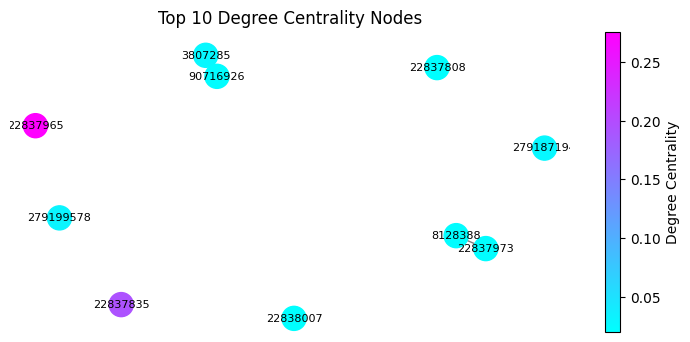

In [25]:
# Degree centrality.
degree_centrality = nx.degree_centrality(G_giant)
top_degree_centrality = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_degree_centrality = pd.DataFrame(top_degree_centrality, columns=['Node', 'Degree Centrality'])

print("Top 10 nodes by degree centrality:")
print("==================================")
print(df_top_degree_centrality)

top_nodes_by_ = df_top_degree_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_)
node_color = [degree_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

nx.draw(subgraph, with_labels=True, node_size=300, edge_color='gray', font_size=8,
        node_color=node_color_normalized, cmap=cmap)
plt.title('Top 10 Degree Centrality Nodes')

# Create ScalarMappable for colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Required for colorbar to work properly
plt.colorbar(sm, label='Degree Centrality', ax=plt.gca())

plt.show()


Top 10 nodes by betweenness centrality:
        Node  Betweenness Centrality
0   22837835                0.553959
1   22837965                0.491607
2   90716926                0.166458
3   22837784                0.165590
4  279187194                0.164591
5    3807285                0.144993
6    3097782                0.113509
7    8128388                0.103709
8    1435388                0.092219
9   21296808                0.086872


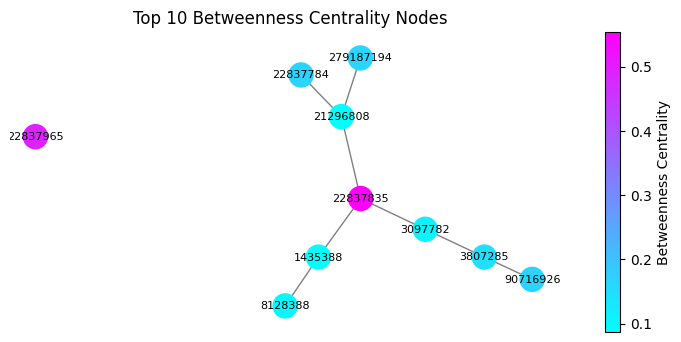

In [26]:
# Betweenness centrality.
betweenness_centrality = nx.betweenness_centrality(G_giant)
top_betweenness_centrality = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_betweenness_centrality = pd.DataFrame(top_betweenness_centrality, columns=['Node', 'Betweenness Centrality'])

print("Top 10 nodes by betweenness centrality:")
print("=======================================")
print(df_top_betweenness_centrality)

top_nodes_by_ = df_top_betweenness_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_)
node_color = [betweenness_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

nx.draw(subgraph, with_labels=True, node_size=300, edge_color='gray', font_size=8,
        node_color=node_color_normalized, cmap=cmap)
plt.title('Top 10 Betweenness Centrality Nodes')

# Create ScalarMappable for colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Required to avoid error
plt.colorbar(sm, label='Betweenness Centrality', ax=plt.gca())

plt.show()


Top 10 nodes by closeness centrality:
        Node  Closeness Centrality
0   22837835              0.317928
1   22837965              0.293814
2    2203811              0.290605
3    1805107              0.285817
4   11447640              0.285817
5    2205152              0.285817
6    1367537              0.285817
7    1437191              0.285817
8   21296808              0.274038
9  279187194              0.271613


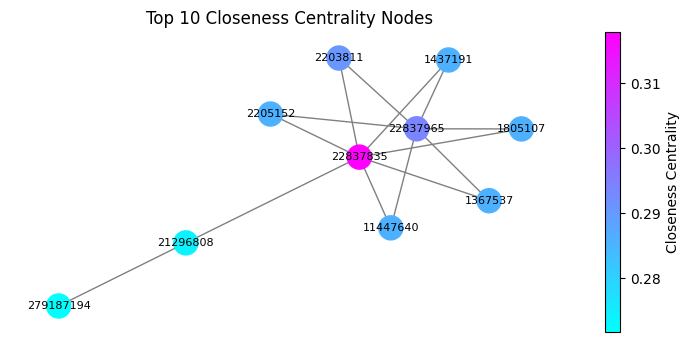

In [27]:
# Closeness centrality.
closeness_centrality = nx.closeness_centrality(G_giant)
top_closeness_centrality = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df_top_closeness_centrality = pd.DataFrame(top_closeness_centrality, columns=['Node', 'Closeness Centrality'])

print("Top 10 nodes by closeness centrality:")
print("=====================================")
print(df_top_closeness_centrality)

top_nodes_by_closeness = df_top_closeness_centrality['Node'].tolist()
subgraph = G_giant.subgraph(top_nodes_by_closeness)
node_color = [closeness_centrality[node] for node in subgraph.nodes()]
norm = mpl.colors.Normalize(vmin=min(node_color), vmax=max(node_color))
node_color_normalized = [norm(value) for value in node_color]
cmap = plt.cm.cool

# -------- #
# Plotting #
# -------- #
plt.figure(figsize=(7, 3))

nx.draw(subgraph, with_labels=True, node_size=300, edge_color='gray', font_size=8,
        node_color=node_color_normalized, cmap=cmap)
plt.title('Top 10 Closeness Centrality Nodes')

# Create ScalarMappable for colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Required for colorbar to work
plt.colorbar(sm, label='Closeness Centrality', ax=plt.gca())

plt.show()


## 🖼️ Graph Visualization

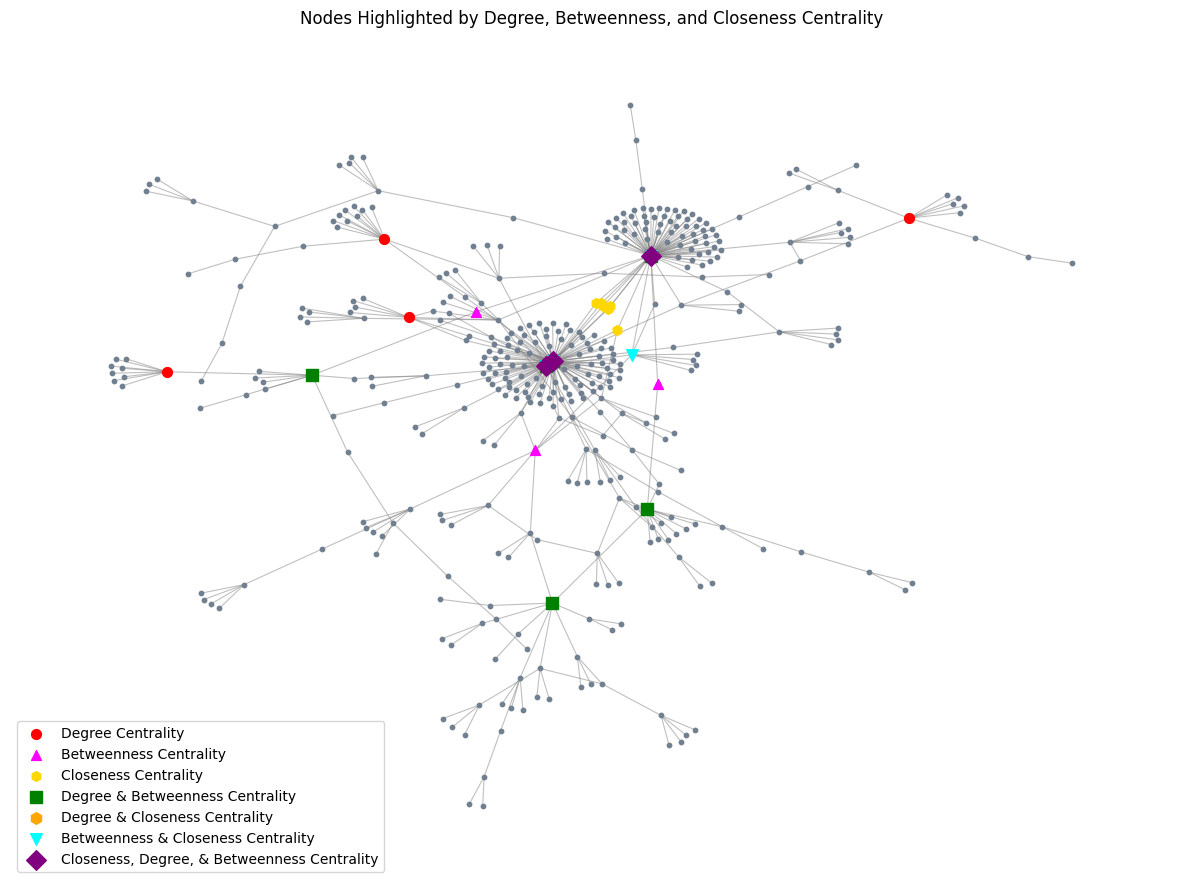

In [28]:
# --------- #
# Preparing #
# --------- #

# Identify nodes that are top in each centrality measure and their combinations.
top_nodes_degree = set([node for node, _ in top_degree_centrality])
top_nodes_betweenness = set([node for node, _ in top_betweenness_centrality])
top_nodes_closeness = set([node for node, _ in top_closeness_centrality])

top_nodes_both = top_nodes_degree.intersection(top_nodes_betweenness)
top_nodes_closeness_and_degree = top_nodes_closeness.intersection(top_nodes_degree)
top_nodes_closeness_and_betweenness = top_nodes_closeness.intersection(top_nodes_betweenness)
top_nodes_all_three = top_nodes_closeness.intersection(top_nodes_degree).intersection(top_nodes_betweenness)

# Assign colors and shapes based on centrality measures.
node_color = []
node_shape = []

for node in G_giant.nodes():
    if node in top_nodes_all_three:
        node_color.append('purple')
        node_shape.append('D')
    elif node in top_nodes_closeness_and_degree:
        node_color.append('orange')
        node_shape.append('h')
    elif node in top_nodes_closeness_and_betweenness:
        node_color.append('cyan')
        node_shape.append('v')
    elif node in top_nodes_both:
        node_color.append('green')
        node_shape.append('s')
    elif node in top_nodes_degree:
        node_color.append('red')
        node_shape.append('o')
    elif node in top_nodes_betweenness:
        node_color.append('magenta')
        node_shape.append('^')
    elif node in top_nodes_closeness:
        node_color.append('yellow')
        node_shape.append('h')
    else:
        node_color.append('slategrey')
        node_shape.append('o')

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(15, 11))

pos = nx.spring_layout(G_giant)
# Draw all nodes first.
nx.draw_networkx_nodes(G_giant, pos, node_color='slategrey', node_size=10)

# Draw nodes with specific centrality measures.
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_degree - top_nodes_both - top_nodes_closeness_and_degree),
                       node_color='red', node_size=50, node_shape='o',
                       label='Degree Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_betweenness - top_nodes_both - top_nodes_closeness_and_betweenness),
                       node_color='magenta', node_size=50, node_shape='^',
                       label='Betweenness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness - top_nodes_closeness_and_degree - top_nodes_closeness_and_betweenness),
                       node_color='gold', node_size=50, node_shape='h',
                       label='Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_both),
                       node_color='green', node_size=80, node_shape='s',
                       label='Degree & Betweenness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness_and_degree),
                       node_color='orange', node_size=70, node_shape='h',
                       label='Degree & Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_closeness_and_betweenness),
                       node_color='cyan', node_size=70, node_shape='v',
                       label='Betweenness & Closeness Centrality')
nx.draw_networkx_nodes(G_giant, pos, nodelist=list(top_nodes_all_three),
                       node_color='purple', node_size=100, node_shape='D',
                       label='Closeness, Degree, & Betweenness Centrality')

# Draw edges.
nx.draw_networkx_edges(G_giant, pos, width=0.8, edge_color='gray', alpha=0.5)

plt.axis('off')
plt.title('Nodes Highlighted by Degree, Betweenness, and Closeness Centrality')
plt.legend(scatterpoints=1)
plt.show()

## 📈 Class-specific Analysis

In [29]:
# Class-based subgraphs.
illicit_nodes = classes_sampled[classes_sampled['class_mapped'] == 'illicit']['txId']
licit_nodes = classes_sampled[classes_sampled['class_mapped'] == 'licit']['txId']

G_illicit = G.subgraph(illicit_nodes)
G_licit = G.subgraph(licit_nodes)

In [30]:
classes_df

,Class Mapped,Class Raw,Counts,Percentage,Emoji
0,unknown,unknown,157205,77.15,🤷
1,licit,2,42019,20.62,✅
2,illicit,1,4545,2.23,❌


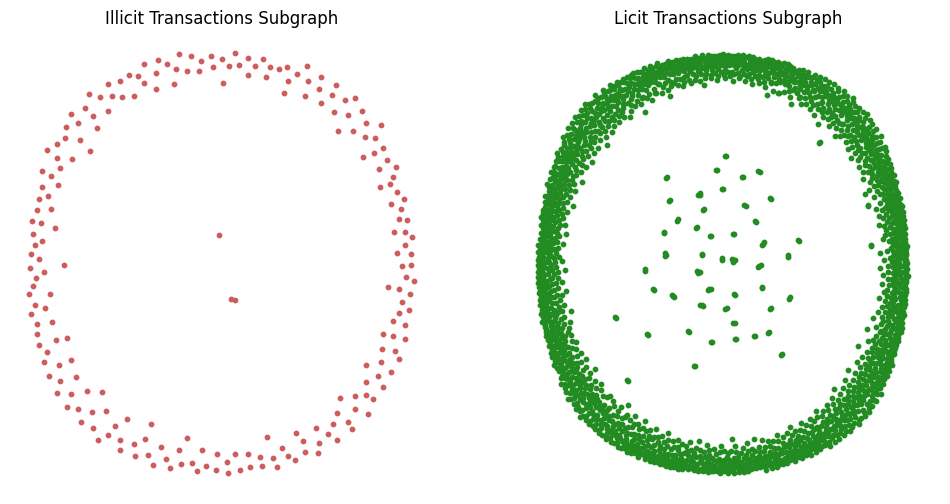

In [31]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
nx.draw(G_illicit, with_labels=False, node_size=10, node_color='indianred', edge_color='black')
plt.title('Illicit Transactions Subgraph')

plt.subplot(1, 2, 2)
nx.draw(G_licit, with_labels=False, node_size=10, node_color='forestgreen', edge_color='black')
plt.title('Licit Transactions Subgraph')

plt.show()

__❌ Illicit Transactions Graph__
- Shows a fairly sparse distribution of nodes, with a ring-like pattern.
- Most nodes are on the periphery, and a few nodes are concentrated in the center.
- Suggests that the __illicit transactions may be less interconnected__, with a __few central nodes potentially acting as hubs__ or key points in the network.

__✅ Licit Transactions Graph__
- The higher density of nodes suggests a more complex network with more transactions or interactions between entities.
- Could imply a more established or legitimate network.
- Suggests that licit transactions may involve more interconnected entities, with many nodes being closely related or interacting more frequently.

# 👥 Community Detection

The goal of community detection is to identify clusters or communities within the graph where nodes are more densely connected internally than with the rest of the graph.

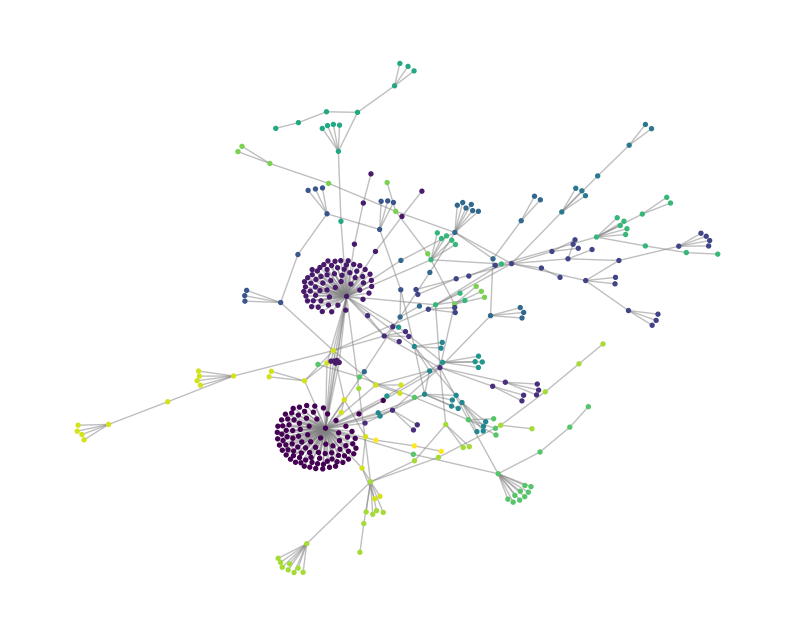

In [32]:
# Compute best partition.
partition = community_louvain.best_partition(G_giant)

# Draw graph.
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_giant)
cmap = plt.get_cmap('viridis')
nx.draw_networkx_nodes(G_giant, pos, node_color=list(partition.values()), node_size=8, cmap=cmap)
nx.draw_networkx_edges(G_giant, pos, alpha=0.5, edge_color='grey')
plt.axis('off')

plt.show()

# 🧠 Graph Neural Networks

Graph Neural Networks (GNNs) are a deep learning technique specifically designed for graph data, useful for tasks like node classification, graph classification, or link prediction. In our case, for now, we will perform ___node prediction___.

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [34]:
metrics_per_gnn = {
    'gcn': {
        'val': {
            'precisions': [],
            'probas': [],
        },
        'test': {
            'licit': {
                'probas': []
            },
            'illicit': {
                'probas': []
            },
        }
    },
    'gat': {
        'val': {
            'precisions': [],
            'probas': [],
        },
        'test': {
            'licit': {
                'probas': []
            },
            'illicit': {
                'probas': []
            },
        }
    },
    'gin': {
        'val': {
            'precisions': [],
            'probas': [],
        },
        'test': {
            'licit': {
                'probas': []
            },
            'illicit': {
                'probas': []
            },
        }
    }
}

## 🛠️ Pre-Processing

In [35]:
num_edges = elliptic_txs_edgelist.shape[0]
num_nodes = elliptic_txs_features.shape[0]

print(f'Number of edges in the graph: {num_edges:8,}')
print(f'Number of nodes in the graph: {num_nodes:8,}')

Number of edges in the graph:  234,355
Number of nodes in the graph:  203,769


In [36]:
# --------------------------------------------------------- #
# Create mapping with txId as key and actual index as value #
# --------------------------------------------------------- #

tx_id_mapping = {tx_id: idx for idx, tx_id in enumerate(elliptic_txs_features['txId'])}

edges_with_features = elliptic_txs_edgelist[elliptic_txs_edgelist['txId1'].isin(list(tx_id_mapping.keys()))\
                                          & elliptic_txs_edgelist['txId2'].isin(list(tx_id_mapping.keys()))]

# This ensures that only valid and known transactions are used for graph-related computations
edges_with_features['Id1'] = edges_with_features['txId1'].map(tx_id_mapping)
edges_with_features['Id2'] = edges_with_features['txId2'].map(tx_id_mapping)

edges_with_features

,txId1,txId2,Id1,Id2
0,230425980,5530458,0,1
1,232022460,232438397,2,3
2,230460314,230459870,4,5
3,230333930,230595899,6,7
4,232013274,232029206,8,9
...,...,...,...,...
234350,158365409,157930723,203602,201430
234351,188708874,188708879,203603,203099
234352,157659064,157659046,201921,202042
234353,87414554,106877725,201480,201368


In [37]:
# converts the processed edge list into a PyTorch tensor

edge_index = torch.tensor(edges_with_features[['Id1', 'Id2']].values.T, dtype=torch.long)
edge_index

tensor([[     0,      2,      4,  ..., 201921, 201480, 201954],
        [     1,      3,      5,  ..., 202042, 201368, 201756]])

In [38]:
# ------------------------------------- #
# Save node features in suitable format #
# ------------------------------------- #

node_features = torch.tensor(elliptic_txs_features.drop(columns=['txId']).values,
                             dtype=torch.float)
print(node_features.shape)
node_features

torch.Size([203769, 166])


tensor([[ 1.0000e+00, -1.7147e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7148e-01, -1.8467e-01,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 1.0000e+00, -1.7211e-01, -1.8467e-01,  ..., -1.8367e-01,
         -1.2061e-01, -1.1979e-01],
        ...,
        [ 4.9000e+01, -1.7201e-01, -7.8182e-02,  ..., -9.7524e-02,
         -1.2061e-01, -1.1979e-01],
        [ 4.9000e+01, -1.7284e-01, -1.7662e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00],
        [ 4.9000e+01, -1.2037e-02, -1.3228e-01,  ..., -1.4060e-01,
          1.5197e+00,  1.5214e+00]])

- 1st dimension tells us about the `# of nodes`
- 2nd dimension tells us about the `# of node features`

In [39]:
elliptic_txs_classes['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [40]:
# ------------------------ #
# Labelencode target class #
# ------------------------ #

le = LabelEncoder()
class_labels = le.fit_transform(elliptic_txs_classes['class'])
node_labels = torch.tensor(class_labels, dtype=torch.long)
original_labels = le.inverse_transform(class_labels)

print(original_labels)
print(class_labels)
print(node_labels)

['unknown' 'unknown' 'unknown' ... '1' 'unknown' 'unknown']
[2 2 2 ... 0 2 2]
tensor([2, 2, 2,  ..., 0, 2, 2])


In [41]:
print(le.inverse_transform([0])) # illicit
print(le.inverse_transform([1])) # licit
print(le.inverse_transform([2])) # unknown

['1']
['2']
['unknown']


In [42]:
# ------------------------------------ #
# Create pytorch geometric Data object #
# ------------------------------------ #

data = Data(x=node_features,
            edge_index=edge_index,
            y=node_labels)

# Move data to GPU.
data = data.to(device)

Now we have created the [pytorch geometric Data object](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.Data.html). However, we still have lots of _unknown_ 🤷 in this object which we dont want to train our GNN on. We only want to train on known nodes, thus, those which are either _licit_ ✅ or _illicit_ ❌.

In [43]:
known_mask   = (data.y == 0) | (data.y == 1)  # Only nodes with known labels licit or illicit
unknown_mask = data.y == 2                    # Nodes with unknown labels

In [44]:
# ------------------------------------------------ #
# Define size for Training, Validation and Testing #
# ------------------------------------------------ #

num_known_nodes = known_mask.sum().item()
permutations = torch.randperm(num_known_nodes)
train_size = int(0.8 * num_known_nodes)
val_size = int(0.1 * num_known_nodes)
test_size = num_known_nodes - train_size - val_size

total = np.sum([train_size, val_size, test_size])

print(f"""Number of observations per split
    Training   : {train_size:10,} ({100*train_size/total:0.2f} %)
    Validation : {val_size:10,} ({100*val_size/total:0.2f} %)
    Testing    : {test_size:10,} ({100*test_size/total:0.2f} %)
""")

Number of observations per split
    Training   :     37,251 (80.00 %)
    Validation :      4,656 (10.00 %)
    Testing    :      4,657 (10.00 %)



Why this matters:

    These masks allow batch processing during training without needing to extract subgraphs.

    PyTorch Geometric uses these masks to automatically apply loss functions and evaluations only to the relevant nodes.

In [45]:
# ----------------------------------------------- #
# Create mask for the indices of Train, Val, Test #
# ----------------------------------------------- #

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_indices = known_mask.nonzero(as_tuple=True)[0][permutations[:train_size]]
val_indices = known_mask.nonzero(as_tuple=True)[0][permutations[train_size:train_size + val_size]]
test_indices = known_mask.nonzero(as_tuple=True)[0][permutations[train_size + val_size:]]

data.train_mask[train_indices] = True
data.val_mask[val_indices] = True
data.test_mask[test_indices] = True

data.train_mask

tensor([False, False, False,  ...,  True, False, False])

In [46]:
# -------------------------- #
# Statistics of the datasets #
# -------------------------- #

train_licit, train_illicit = (data.y[data.train_mask] == 1).sum().item(), (data.y[data.train_mask] == 0).sum().item()
val_licit, val_illicit = (data.y[data.val_mask] == 1).sum().item(), (data.y[data.val_mask] == 0).sum().item()
test_licit, test_illicit = (data.y[data.test_mask] == 1).sum().item(), (data.y[data.test_mask] == 0).sum().item()

# Calculate total counts.
train_total = train_licit + train_illicit
val_total = val_licit + val_illicit
test_total = test_licit + test_illicit

# Calculate percentages.
train_licit_pct = (train_licit / train_total) * 100
train_illicit_pct = (train_illicit / train_total) * 100
val_licit_pct = (val_licit / val_total) * 100
val_illicit_pct = (val_illicit / val_total) * 100
test_licit_pct = (test_licit / test_total) * 100
test_illicit_pct = (test_illicit / test_total) * 100

pd.DataFrame({
    'Set': ['Training', 'Validation', 'Testing'],
    'Total Count': [train_total, val_total, test_total],
    'Licit': [train_licit, val_licit, test_licit],
    'Licit (%)': [train_licit_pct, val_licit_pct, test_licit_pct],
    'Illicit': [train_illicit, val_illicit, test_illicit],
    'Illicit (%)': [train_illicit_pct, val_illicit_pct, test_illicit_pct]
})

,Set,Total Count,Licit,Licit (%),Illicit,Illicit (%)
0,Training,37251,33649,90.330461,3602,9.669539
1,Validation,4656,4148,89.089347,508,10.910653
2,Testing,4657,4222,90.659223,435,9.340777


The percentages are pretty similar over all datasets, which is what we want.

In [47]:
mapped_classes = np.array(['illicit', 'licit'])

In [48]:
# ------------------------------------- #
# Define Focal Loss for class imbalance #
# ------------------------------------- #

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Class weighting
        self.gamma = gamma  # Focusing parameter
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)  # pt = softmax probability of the true class
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class_counts = torch.tensor([5000, 3000, 20000], dtype=torch.float32)  # adjust to your dataset
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalize
class_weights = class_weights.to(device)

## 1️⃣ - GCN - Graph Convolutional Networks

The core idea of a _Graph Convolutional Networks_ (GCN) is to aggregate features from a node's local neighborhood. The feature aggregation is performed using a convolution operation adapted for graph structures.

$$
H^{(l+1)} = \sigma\left( \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}} H^{(l)} W^{(l)} \right)
$$

- $H^{(l)}$: Node feature matrix at layer $l$.
- $\tilde{A} = A + I$: Adjacency matrix with added self-loops.
- $\tilde{D}$: Diagonal degree matrix of $\tilde{A}$.
- $W^{(l)}$: Trainable weight matrix at layer $l$.
- $\sigma$: Activation function (e.g., ReLU).

In [49]:
# -------------- #
# Define the GCN #
# -------------- #

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# ---------- #
# Initialize #
# ---------- #

gcn_model = GCN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(gcn_model.parameters(),
                             lr=0.01,
                             weight_decay=0.0005)
criterion = torch.nn.CrossEntropyLoss()  # Since we have a multiclass classification problem.
# criterion = FocalLoss(alpha=class_weights, gamma=args.gamma)

data = data.to(device)

In [50]:
# ------ #
# Train  #
# ------ #

train_val_metrics = train_gnn(NUM_EPOCHS,
                              data,
                              gcn_model,
                              optimizer,
                              criterion)

metrics_per_gnn['gcn']['val']['precisions'] = train_val_metrics['val']['precisions']

Epoch 010, Loss: 0.4143, Train - Acc: 0.8988 - Prec: 0.8662 - Rec: 0.8988 - F1: 0.8737
                         Val   - Acc: 0.8915 - Prec: 0.8586 - Rec: 0.8915 - F1: 0.8595
Epoch 020, Loss: 0.3295, Train - Acc: 0.9047 - Prec: 0.8763 - Rec: 0.9047 - F1: 0.8674
                         Val   - Acc: 0.8950 - Prec: 0.8743 - Rec: 0.8950 - F1: 0.8548
Epoch 030, Loss: 0.2562, Train - Acc: 0.8915 - Prec: 0.8907 - Rec: 0.8915 - F1: 0.8911
                         Val   - Acc: 0.8877 - Prec: 0.8846 - Rec: 0.8877 - F1: 0.8861
Epoch 040, Loss: 0.2294, Train - Acc: 0.9072 - Prec: 0.8893 - Rec: 0.9072 - F1: 0.8937
                         Val   - Acc: 0.9003 - Prec: 0.8810 - Rec: 0.9003 - F1: 0.8818
Epoch 050, Loss: 0.2182, Train - Acc: 0.9073 - Prec: 0.8846 - Rec: 0.9073 - F1: 0.8751
                         Val   - Acc: 0.8969 - Prec: 0.8764 - Rec: 0.8969 - F1: 0.8625
Epoch 060, Loss: 0.2058, Train - Acc: 0.9190 - Prec: 0.9073 - Rec: 0.9190 - F1: 0.9002
                         Val   - Acc: 0.912

In [51]:
# -------- #
# Evaluate #
# -------- #

gcn_model.eval()
with torch.no_grad():

    test_metrics = evaluate(gcn_model, data, data.test_mask)
    test_acc = test_metrics.get('accuracy')
    test_prec = test_metrics.get('precision')
    test_rec = test_metrics.get('recall')
    test_f1 = test_metrics.get('f1_score')

    print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

Test Acc: 0.9431 - Prec: 0.9394 - Rec: 0.9431 - F1: 0.9353


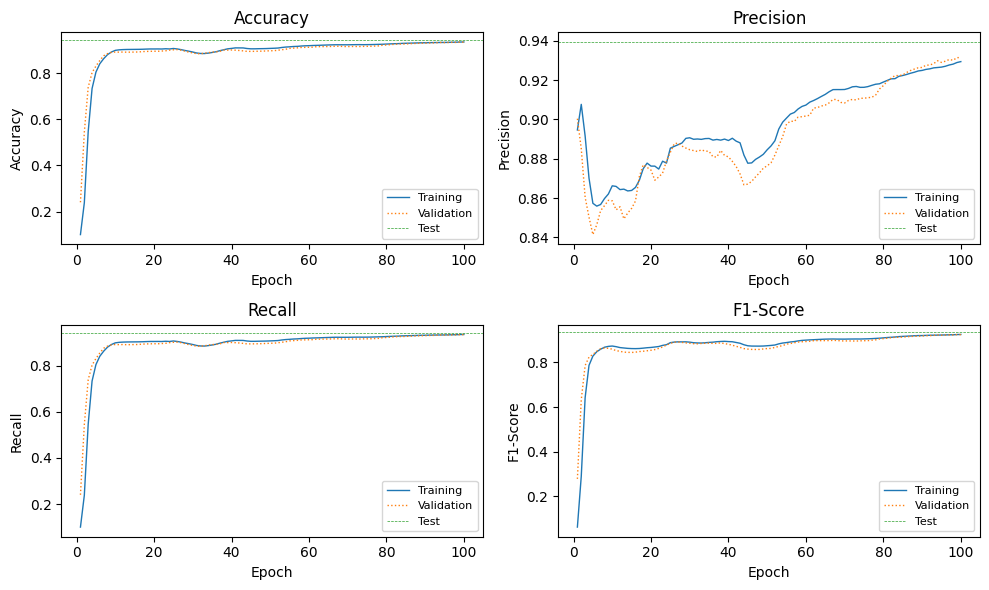

In [52]:
plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

In [53]:
train_pred = predict(gcn_model, data)[data.train_mask]
test_pred = predict(gcn_model, data)[data.test_mask]

In [54]:
print(le.inverse_transform([0])) # illicit
print(le.inverse_transform([1])) # licit
print(le.inverse_transform([2])) # unknown

['1']
['2']
['unknown']


In [55]:
# --- Classification report ---
print("Classification Report")
print("=====================\n")

# Train.
y_true_train = data.y[data.train_mask].cpu().numpy()
y_pred_train = train_pred.cpu().numpy()

report_train = classification_report(y_true_train, y_pred_train, target_names=mapped_classes)

print(f"{4*' '}TRAIN")
print("---------")
print(report_train)

# Test.
y_true_test = data.y[data.test_mask].cpu().numpy()
y_pred_test = test_pred.cpu().numpy()

report_test = classification_report(y_true_test, y_pred_test, target_names=mapped_classes)

print(f"{4*' '}TEST")
print("--------")
print(report_test)

Classification Report

    TRAIN
---------
              precision    recall  f1-score   support

     illicit       0.82      0.43      0.56      3602
       licit       0.94      0.99      0.97     33649

    accuracy                           0.94     37251
   macro avg       0.88      0.71      0.76     37251
weighted avg       0.93      0.94      0.93     37251

    TEST
--------
              precision    recall  f1-score   support

     illicit       0.86      0.47      0.61       435
       licit       0.95      0.99      0.97      4222

    accuracy                           0.94      4657
   macro avg       0.90      0.73      0.79      4657
weighted avg       0.94      0.94      0.94      4657



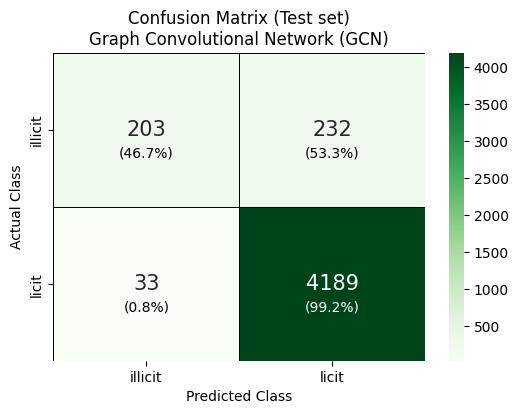

In [56]:
mapped_classes = np.array(['illicit', 'licit'])

# --- Confusion matrix ---
cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens,
            annot_kws={'size': 15},
            xticklabels=mapped_classes,
            yticklabels=mapped_classes,
            linecolor='black', linewidth=0.5,
            ax=ax)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Annotate each cell with the percentage of that row.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text = f'\n({percentage:.1f}%)'
        color = 'white' if percentage > 95 else 'black'
        ax.text(j + 0.5, i + 0.6, text,
                ha='center', va='center', fontsize=10, color=color)

plt.title('Confusion Matrix (Test set)\nGraph Convolutional Network (GCN)')
plt.show()

- The model is very good at predicting `unknown` class. Simply because it's the majority of the dataset.
- The GCN is also decent at predicting if a node is `licit` or not. However, it predicted 42% of all `licit` nodes as being `unknown`.
- The model is decent but unsure at predicting `illicit` nodes. It only classified 46% of all `illicit` nodes correctly.

In [57]:
train_probas = predict_probabilities(gcn_model, data)[data.train_mask]
test_probas = predict_probabilities(gcn_model, data)[data.test_mask]

In [58]:
train_probas_illicit = train_probas[:, 1].cpu().numpy()
train_probas_illicit

array([1.        , 1.        , 0.927976  , ..., 0.9997477 , 0.9945425 ,
       0.87906814], dtype=float32)

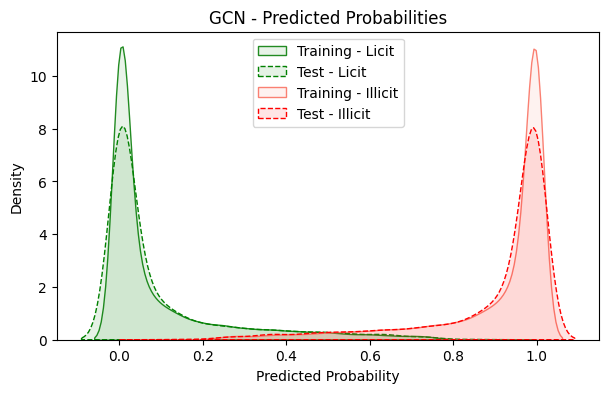

In [59]:
ALPHA = 0.1

train_probas_licit = train_probas[:, 0].cpu().numpy()
train_probas_illicit = train_probas[:, 1].cpu().numpy()

test_probas_licit = test_probas[:, 0].cpu().numpy()
test_probas_illicit = test_probas[:, 1].cpu().numpy()

metrics_per_gnn['gcn']['test']['licit']['probas'] = test_probas_licit
metrics_per_gnn['gcn']['test']['illicit']['probas'] = test_probas_illicit

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(7, 4))

# Plot licit class probabilities
sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# Plot illicit class probabilities
sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

plt.title("GCN - Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center")

plt.show()

## 2️⃣ - GAT - Graph Attention Networks

_Graph Attention Networks_ (GAT) introduce attention mechanisms to graphs, where the importance of neighboring nodes is learned via attention coefficients.

$$
h_i^{(l+1)} = \sigma\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(l)} W^{(l)} h_j^{(l)} \right)
$$

- $h_i^{(l)}$: Feature vector of node $i$ at layer $l$.
- $\mathcal{N}(i)$: Set of neighbors of node $i$.
- $\alpha_{ij}^{(l)}$: Attention coefficient between node $i$ and node $j$.
- $W^{(l)}$: Trainable weight matrix.
- $\sigma$: Activation function.

The attention coefficients $\alpha_{ij}^{(l)}$ are computed as:

$$
\alpha_{ij}^{(l)} = \frac{\exp\left(\text{LeakyReLU}\left(\mathbf{a}^T \left[W^{(l)} h_i^{(l)} \, \| \, W^{(l)} h_j^{(l)}\right]\right)\right)}{\sum_{k \in \mathcal{N}(i)} \exp\left(\text{LeakyReLU}\left(\mathbf{a}^T \left[W^{(l)} h_i^{(l)} \, \| \, W^{(l)} h_k^{(l)}\right]\right)\right)}
$$

- $\mathbf{a}$: Attention mechanism parameter vector.
- $\|$: Concatenation operation.

In [60]:
# -------------- #
# Define the GAT #
# -------------- #

class GAT(torch.nn.Module):
    def __init__(self, num_node_features, num_classes, num_heads=8):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_node_features, 8, heads=num_heads, dropout=0.6)
        self.conv2 = GATConv(8 * num_heads, num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# ---------- #
# Initialize #
# ---------- #

gat_model = GAT(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01, weight_decay=0.0005)
criterion = torch.nn.CrossEntropyLoss()  # Since we have a multiclass classification problem.

data = data.to(device)

In [61]:
# ----- #
# Train #
# ----- #

train_val_metrics = train_gnn(NUM_EPOCHS,
                              data,
                              gat_model,
                              optimizer,
                              criterion)

metrics_per_gnn['gat']['val']['precisions'] = train_val_metrics['val']['precisions']

Epoch 010, Loss: 0.7362, Train - Acc: 0.8829 - Prec: 0.8634 - Rec: 0.8829 - F1: 0.8716
                         Val   - Acc: 0.8868 - Prec: 0.8844 - Rec: 0.8868 - F1: 0.8856
Epoch 020, Loss: 0.5729, Train - Acc: 0.8984 - Prec: 0.8747 - Rec: 0.8984 - F1: 0.8820
                         Val   - Acc: 0.8567 - Prec: 0.8935 - Rec: 0.8567 - F1: 0.8707
Epoch 030, Loss: 0.5020, Train - Acc: 0.9057 - Prec: 0.8814 - Rec: 0.9057 - F1: 0.8842
                         Val   - Acc: 0.8804 - Prec: 0.9045 - Rec: 0.8804 - F1: 0.8897
Epoch 040, Loss: 0.4479, Train - Acc: 0.9128 - Prec: 0.8958 - Rec: 0.9128 - F1: 0.8901
                         Val   - Acc: 0.9156 - Prec: 0.9196 - Rec: 0.9156 - F1: 0.9174
Epoch 050, Loss: 0.4142, Train - Acc: 0.9143 - Prec: 0.8989 - Rec: 0.9143 - F1: 0.8925
                         Val   - Acc: 0.9287 - Prec: 0.9256 - Rec: 0.9287 - F1: 0.9269
Epoch 060, Loss: 0.3809, Train - Acc: 0.9184 - Prec: 0.9084 - Rec: 0.9184 - F1: 0.8970
                         Val   - Acc: 0.939

In [62]:
# -------- #
# Evaluate #
# -------- #

gat_model.eval()
with torch.no_grad():

    test_metrics = evaluate(gat_model, data, data.test_mask)
    test_acc = test_metrics.get('accuracy')
    test_prec = test_metrics.get('precision')
    test_rec = test_metrics.get('recall')
    test_f1 = test_metrics.get('f1_score')

    print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

Test Acc: 0.9472 - Prec: 0.9438 - Rec: 0.9472 - F1: 0.9411


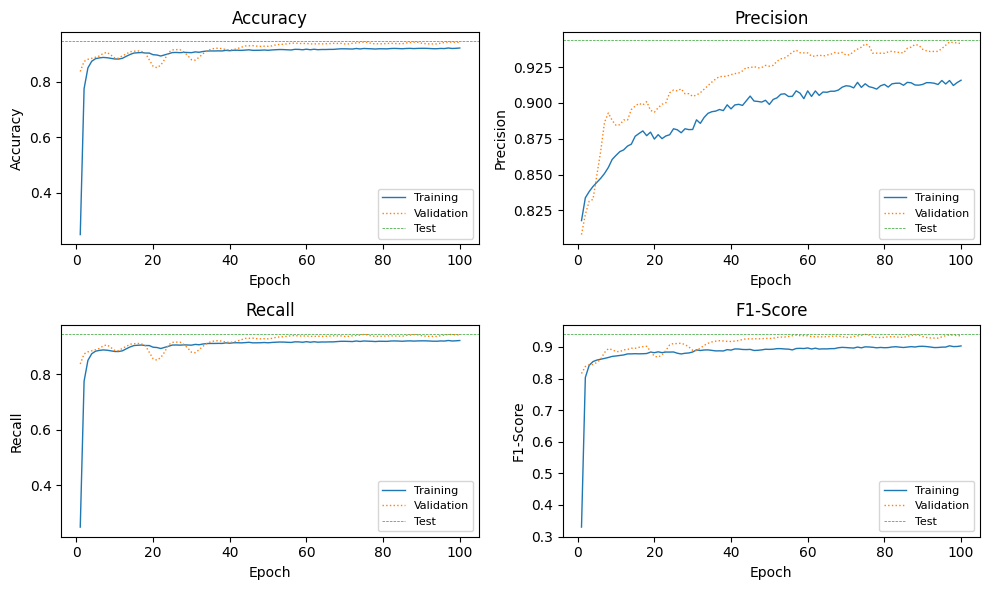

In [63]:
plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

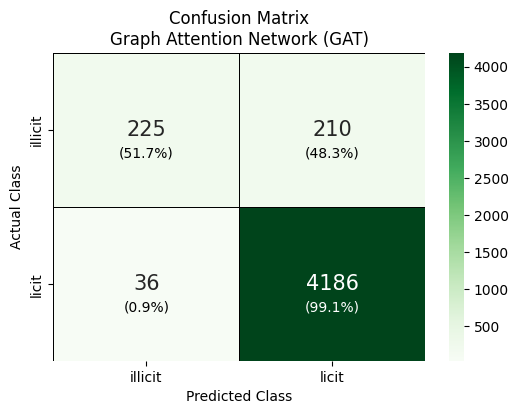

In [64]:
test_pred = predict(gat_model, data)[data.test_mask]

# --- Confusion matrix ---
cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens,
            annot_kws={'size': 15},
            xticklabels=mapped_classes,
            yticklabels=mapped_classes,
            linecolor='black', linewidth=0.5,
            ax=ax)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Annotate each cell with the percentage of that row.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text = f'\n({percentage:.1f}%)'
        color = 'white' if percentage > 95 else 'black'
        ax.text(j + 0.5, i + 0.6, text,
                ha='center', va='center', fontsize=10, color=color)

plt.title('Confusion Matrix\nGraph Attention Network (GAT)')
plt.show()

In [65]:
train_probas = predict_probabilities(gat_model, data)[data.train_mask]
test_probas = predict_probabilities(gat_model, data)[data.test_mask]

In [66]:
train_probas_illicit = train_probas[:, 1].cpu().numpy()
train_probas_illicit

array([0.980067  , 0.98649365, 0.9076386 , ..., 0.99958605, 0.9754082 ,
       0.70485973], dtype=float32)

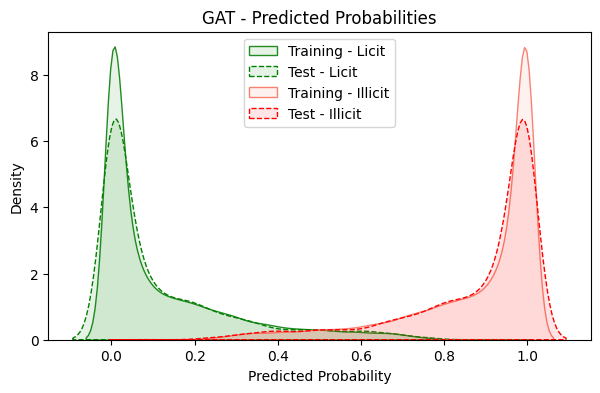

In [67]:
ALPHA = 0.1

train_probas_licit = train_probas[:, 0].cpu().numpy()
train_probas_illicit = train_probas[:, 1].cpu().numpy()

test_probas_licit = test_probas[:, 0].cpu().numpy()
test_probas_illicit = test_probas[:, 1].cpu().numpy()

metrics_per_gnn['gat']['test']['licit']['probas'] = test_probas_licit
metrics_per_gnn['gat']['test']['illicit']['probas'] = test_probas_illicit

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(7, 4))

# Plot licit class probabilities
sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# Plot illicit class probabilities
sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

plt.title("GAT - Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center")

plt.show()

## 3️⃣ - GIN - Graph Isomorphism Networks

_Graph Isomorphism Networks_ (GINs) are designed to be as powerful as the Weisfeiler-Lehman graph isomorphism test, focusing on distinguishing graph structures.

$$
h_i^{(l+1)} = \text{MLP}^{(l)}\left( (1 + \epsilon) \cdot h_i^{(l)} + \sum_{j \in \mathcal{N}(i)} h_j^{(l)} \right)
$$

- $h_i^{(l)}$: Feature vector of node $i$ at layer $l$.
- $\mathcal{N}(i)$: Set of neighbors of node $i$.
- $\epsilon$: Learnable or fixed scalar.
- $\text{MLP}^{(l)}$: Multi-layer perceptron at layer $l$.

GIN aggregates neighboring node features and then applies an MLP to produce the next layer's node features. The inclusion of $\epsilon$ allows for distinguishing between a node and its neighbors.

In [68]:
# -------------- #
# Define the GIN #
# -------------- #7

from torch_geometric.nn import GINConv, global_add_pool
import torch.nn.functional as F

class GIN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GIN, self).__init__()

        # 1st GIN layer.
        nn1 = torch.nn.Sequential(
            torch.nn.Linear(num_node_features, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64)
        )
        self.conv1 = GINConv(nn1)

        # 2nd GIN layer.
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64)
        )
        self.conv2 = GINConv(nn2)
        self.fc = torch.nn.Linear(64, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
#         x = global_add_pool(x, batch)
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

# ---------- #
# Initialize #
# ---------- #

gin_model = GIN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(gin_model.parameters(), lr=0.01, weight_decay=0.0005)
criterion = torch.nn.CrossEntropyLoss()

# # Handle the class imbalance
# class_counts = torch.bincount(data.y)
# class_weights = 1. / class_counts.float()
# criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

data = data.to(device)

In [69]:
# ----- #
# Train #
# ----- #

train_val_metrics = train_gnn(NUM_EPOCHS,
                              data,
                              gin_model,
                              optimizer,
                              criterion)

metrics_per_gnn['gin']['val']['precisions'] = train_val_metrics['val']['precisions']

Epoch 010, Loss: 0.2738, Train - Acc: 0.9033 - Prec: 0.8160 - Rec: 0.9033 - F1: 0.8574
                         Val   - Acc: 0.8909 - Prec: 0.7937 - Rec: 0.8909 - F1: 0.8395
Epoch 020, Loss: 0.2350, Train - Acc: 0.9033 - Prec: 0.9127 - Rec: 0.9033 - F1: 0.8575
                         Val   - Acc: 0.8900 - Prec: 0.7936 - Rec: 0.8900 - F1: 0.8391
Epoch 030, Loss: 0.2046, Train - Acc: 0.9018 - Prec: 0.8412 - Rec: 0.9018 - F1: 0.8581
                         Val   - Acc: 0.8905 - Prec: 0.8379 - Rec: 0.8905 - F1: 0.8409
Epoch 040, Loss: 0.1646, Train - Acc: 0.9250 - Prec: 0.9190 - Rec: 0.9250 - F1: 0.9077
                         Val   - Acc: 0.9195 - Prec: 0.9194 - Rec: 0.9195 - F1: 0.9000
Epoch 050, Loss: 0.1340, Train - Acc: 0.9495 - Prec: 0.9463 - Rec: 0.9495 - F1: 0.9450
                         Val   - Acc: 0.9506 - Prec: 0.9482 - Rec: 0.9506 - F1: 0.9471
Epoch 060, Loss: 0.1202, Train - Acc: 0.9550 - Prec: 0.9533 - Rec: 0.9550 - F1: 0.9507
                         Val   - Acc: 0.951

In [70]:
# -------- #
# Evaluate #
# -------- #

gin_model.eval()
with torch.no_grad():

    test_metrics = evaluate(gin_model, data, data.test_mask)
    test_acc = test_metrics.get('accuracy')
    test_prec = test_metrics.get('precision')
    test_rec = test_metrics.get('recall')
    test_f1 = test_metrics.get('f1_score')

    print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

Test Acc: 0.9586 - Prec: 0.9573 - Rec: 0.9586 - F1: 0.9578


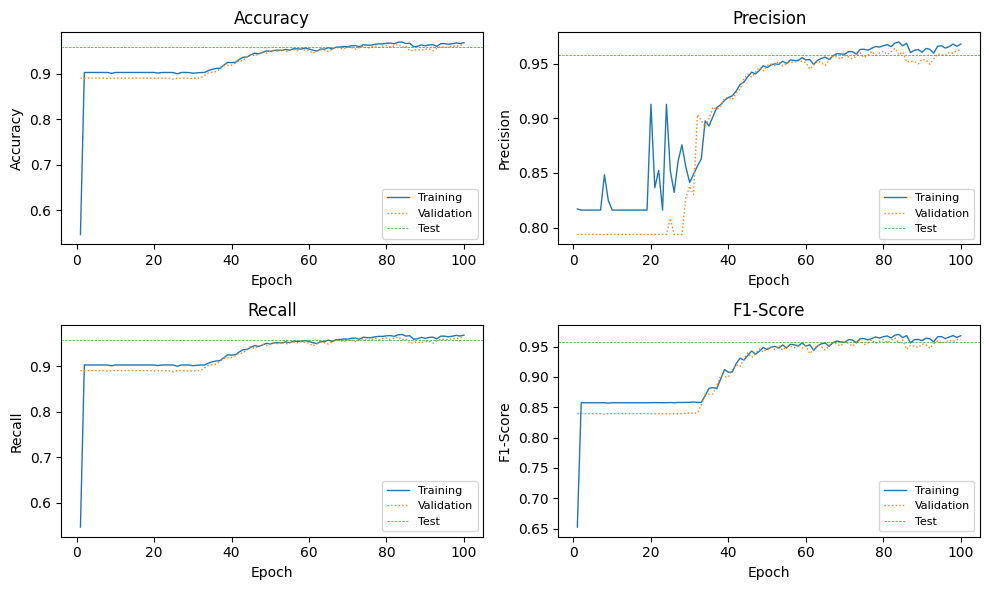

In [71]:
plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

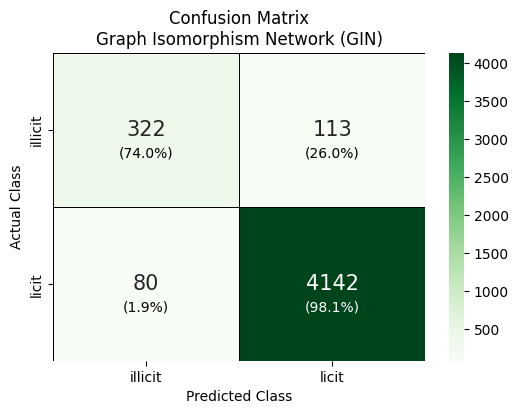

In [72]:
test_pred = predict(gin_model, data)[data.test_mask]

# --- Confusion matrix ---
cm = confusion_matrix(data.y[data.test_mask].cpu(), test_pred.cpu())

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='g', cmap=plt.cm.Greens,
            annot_kws={'size': 15},
            xticklabels=mapped_classes,
            yticklabels=mapped_classes,
            linecolor='black', linewidth=0.5,
            ax=ax)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Annotate each cell with the percentage of that row.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text = f'\n({percentage:.1f}%)'
        color = 'white' if percentage > 95 else 'black'
        ax.text(j + 0.5, i + 0.6, text,
                ha='center', va='center', fontsize=10, color=color)

plt.title('Confusion Matrix\nGraph Isomorphism Network (GIN)')
plt.show()

In [73]:
train_probas = predict_probabilities(gin_model, data)[data.train_mask]
test_probas = predict_probabilities(gin_model, data)[data.test_mask]

In [74]:
train_probas_illicit = train_probas[:, 1].cpu().numpy()
train_probas_illicit

array([1.        , 1.        , 0.9935992 , ..., 0.9996144 , 0.91378945,
       0.25770566], dtype=float32)

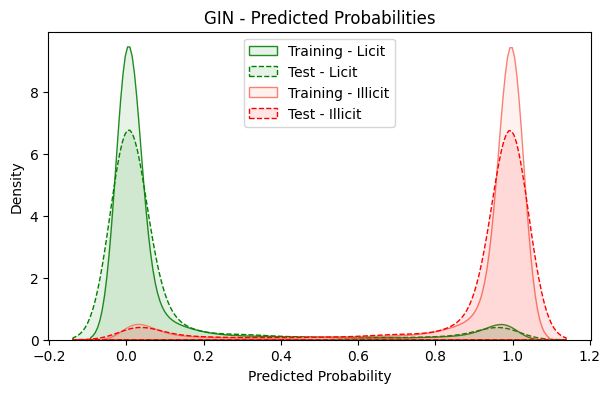

In [75]:
ALPHA = 0.1

train_probas_licit = train_probas[:, 0].cpu().numpy()
train_probas_illicit = train_probas[:, 1].cpu().numpy()

test_probas_licit = test_probas[:, 0].cpu().numpy()
test_probas_illicit = test_probas[:, 1].cpu().numpy()

metrics_per_gnn['gin']['test']['licit']['probas'] = test_probas_licit
metrics_per_gnn['gin']['test']['illicit']['probas'] = test_probas_illicit

# -------- #
# Plotting #
# -------- #

plt.figure(figsize=(7, 4))

# Plot licit class probabilities
sns.kdeplot(train_probas_licit, fill=True, color="forestgreen", linestyle='-', alpha=ALPHA, label="Training - Licit")
sns.kdeplot(test_probas_licit, fill=True, color="green", linestyle='--', alpha=ALPHA, label="Test - Licit")

# Plot illicit class probabilities
sns.kdeplot(train_probas_illicit, fill=True, color="salmon", linestyle='-', alpha=ALPHA, label="Training - Illicit")
sns.kdeplot(test_probas_illicit, fill=True, color="red", linestyle='--', alpha=ALPHA, label="Test - Illicit")

plt.title("GIN - Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center")

plt.show()

## 4️⃣ - EvolveGCN - considering the temporal feature of bitcoin transactions

In [76]:
# 1. Model Definition: EvolveGCN_H

class EvolvingGCNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(EvolvingGCNLayer, self).__init__()
        self.gcn = GCNConv(in_channels, out_channels, bias=False)

        # Evolve W with shape [out_channels, in_channels]
        self.W = nn.Parameter(torch.Tensor(out_channels, in_channels))
        self.gru = nn.GRUCell(out_channels * in_channels, out_channels * in_channels)

        torch.nn.init.xavier_uniform_(self.W.data)

    def forward(self, x, edge_index, h=None):
        # Apply current evolved weight to the GCN layer
        self.gcn.lin.weight = self.W

        x = self.gcn(x, edge_index)

        # Flatten W for GRU evolution
        W_flat = self.W.view(1, -1)  # shape [1, out_channels * in_channels]
        if h is None:
            h = torch.zeros_like(W_flat)
        W_next = self.gru(W_flat, h)

        # Update W
        self.W = nn.Parameter(W_next.view(self.W.shape))
        return F.relu(x), W_next


class EvolveGCN_H(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super(EvolveGCN_H, self).__init__()
        self.layer1 = EvolvingGCNLayer(in_channels, hidden_channels)
        self.layer2 = EvolvingGCNLayer(hidden_channels, num_classes)

    def forward(self, data_list):
        h1, h2 = None, None
        x_out = None

        for data in data_list:
            x, edge_index = data.x, data.edge_index
            if x is None or edge_index.size(1) == 0:
                continue

            x, h1 = self.layer1(x, edge_index, h1)
            x, h2 = self.layer2(x, edge_index, h2)
            x_out = x

        if x_out is None:
            raise ValueError("No valid graphs in data_list for EvolveGCN forward pass.")

        return F.log_softmax(x_out, dim=1)


In [77]:
# 2. Training & Evaluation Functions

from sklearn.metrics import f1_score, confusion_matrix

def train_evolvegcn(model, data_list, optimizer, criterion, device):
    model.train()
    optimizer.zero_grad()
    out = model([d.to(device) for d in data_list])
    # labels = torch.cat([d.y for d in data_list]).to(device)
    labels = data_list[-1].y.to(device)
    loss = criterion(out, labels)
    loss.backward()
    optimizer.step()

    preds = out.argmax(dim=1).cpu()
    true = labels.cpu()
    f1 = f1_score(true, preds, average='macro')
    conf_matrix = confusion_matrix(true, preds)
    return loss.item(), f1, conf_matrix

def test_evolvegcn(model, data_list, criterion, device):
    model.eval()
    with torch.no_grad():
        out = model([d.to(device) for d in data_list])
        # labels = torch.cat([d.y for d in data_list]).to(device)
        labels = data_list[-1].y.to(device)
        loss = criterion(out, labels)

        preds = out.argmax(dim=1).cpu()
        true = labels.cpu()
        f1 = f1_score(true, preds, average='macro')
        conf_matrix = confusion_matrix(true, preds)
    return loss.item(), f1, conf_matrix


### Train EvolveGCN

In [78]:
# Load node features (with time_step, features, and class label)
features_df = pd.read_csv('/content/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)
features_df.columns = ['tx_id'] + [f'f_{i}' for i in range(1, 166)] + ['time_step']
print("Features shape:", features_df.shape)

# Load class labels
classes_df = pd.read_csv('/content/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
classes_df.columns = ['tx_id', 'class']

# Merge to attach class labels to feature rows
features_df = features_df.merge(classes_df, on='tx_id')


Features shape: (203769, 167)


In [79]:
# Label encode the classes

features_df = features_df[features_df['class'] != 'unknown']  # optional: filter unknowns
le = LabelEncoder()
features_df['label'] = le.fit_transform(features_df['class'])  # licit=0, illicit=1

In [80]:
edges_df = pd.read_csv('/content/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
edges_df.columns = ['source', 'target']

In [81]:
# 3. Convert to PyG Data Objects (per time step)

from collections import defaultdict

data_list = []

# Group nodes by time step
grouped = features_df.groupby('time_step')

for time_step, group in grouped:
    nodes = group['tx_id'].values
    node_id_map = {tx_id: i for i, tx_id in enumerate(nodes)}

    x = torch.tensor(group[[f"f_{i}" for i in range(1, 166)]].values, dtype=torch.float)
    y = torch.tensor(group['label'].values, dtype=torch.long)

    # Filter edges that connect nodes in this timestep
    edges = edges_df[
        edges_df['source'].isin(nodes) & edges_df['target'].isin(nodes)
    ].copy()

    if edges.empty:
        continue

    # Map tx_ids to indices in the current timestep graph
    src = edges['source'].map(node_id_map)
    tgt = edges['target'].map(node_id_map)
    edge_index = torch.tensor([src.values, tgt.values], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.time_step = int(time_step)
    data_list.append(data)

<ipython-input-81-9b66b6236b65>:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  edge_index = torch.tensor([src.values, tgt.values], dtype=torch.long)


In [82]:
# 4. Training Loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

evolve_model = EvolveGCN_H(
    in_channels=data_list[0].num_features,
    hidden_channels=16,
    num_classes=len(le.classes_)
).to(device)

criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(evolve_model.parameters(), lr=0.001)

# Train/test split
split_idx = int(0.7 * len(data_list))
train_data_list = data_list[:split_idx]
test_data_list = data_list[split_idx:]

NUM_EPOCHS = 100
for epoch in range(NUM_EPOCHS):
    train_loss, train_f1, train_conf = train_evolvegcn(evolve_model, train_data_list, optimizer, criterion, device)
    test_loss, test_f1, test_conf = test_evolvegcn(evolve_model, test_data_list, criterion, device)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f" Train Loss: {train_loss:.4f}, F1: {train_f1:.4f}")
    print(f" Test  Loss: {test_loss:.4f}, F1: {test_f1:.4f}")
    print(" Test Confusion Matrix:\n", test_conf)
    print("-" * 40)


Epoch 1/100
 Train Loss: 0.7187, F1: 0.1130
 Test  Loss: 0.7318, F1: 0.1594
 Test Confusion Matrix:
 [[ 312   39]
 [7203 1140]]
----------------------------------------
Epoch 2/100
 Train Loss: 0.7334, F1: 0.0547
 Test  Loss: 0.7406, F1: 0.1393
 Test Confusion Matrix:
 [[ 329   22]
 [7427  916]]
----------------------------------------
Epoch 3/100
 Train Loss: 0.7339, F1: 0.0547
 Test  Loss: 0.7407, F1: 0.1395
 Test Confusion Matrix:
 [[ 329   22]
 [7425  918]]
----------------------------------------
Epoch 4/100
 Train Loss: 0.7339, F1: 0.0547
 Test  Loss: 0.7407, F1: 0.1395
 Test Confusion Matrix:
 [[ 329   22]
 [7425  918]]
----------------------------------------
Epoch 5/100
 Train Loss: 0.7339, F1: 0.0547
 Test  Loss: 0.7407, F1: 0.1395
 Test Confusion Matrix:
 [[ 329   22]
 [7425  918]]
----------------------------------------
Epoch 6/100
 Train Loss: 0.7339, F1: 0.0547
 Test  Loss: 0.7407, F1: 0.1395
 Test Confusion Matrix:
 [[ 329   22]
 [7425  918]]
---------------------------

## PCA and T-SNE

In [83]:
from sklearn.manifold import TSNE
from cuml.manifold import TSNE as cuTSNE
from sklearn.decomposition import PCA

In [84]:
# def apply_pca_and_inverse(data, num_components):
#     # Extract original features and convert to NumPy
#     original_features = data.x.cpu().numpy()

#     # Fit PCA
#     pca = PCA(n_components=num_components)
#     pca_components = pca.fit_transform(original_features)

#     # Inverse transform to get features back in original dimension
#     reconstructed_features = pca.inverse_transform(pca_components)

#     # Clone data and set new x
#     data_pca = data.clone()
#     data_pca.x = torch.tensor(reconstructed_features, dtype=torch.float, device=data.x.device)

#     # ----- Manually copy custom attributes like train/val/test masks -----
#     data_pca.train_mask = data.train_mask.clone()
#     data_pca.val_mask = data.val_mask.clone()
#     data_pca.test_mask = data.test_mask.clone()

#     return data_pca, pca


# NUM_PCA_COMPONENTS = 32
# data_pca, pca = apply_pca_and_inverse(data, NUM_PCA_COMPONENTS)
# data_pca = data_pca.to(device)

AttributeError: 'GlobalStorage' object has no attribute 'train_mask'

In [ ]:
# gcn_pca_model = GCN(num_node_features=data.num_features, num_classes=len(le.classes_)).to(device)

In [ ]:
# train_val_metrics = train_gnn(NUM_EPOCHS,
#                               data_pca,         # <---- use PCA-transformed data
#                               gcn_pca_model,
#                               optimizer,
#                               criterion)

# metrics_per_gnn['gcn']['val']['precisions'] = train_val_metrics['val']['precisions']


In [ ]:
# # -------- #
# # Evaluate #
# # -------- #

# gcn_pca_model.eval()
# with torch.no_grad():

#     test_metrics = evaluate(gcn_pca_model, data_pca, data_pca.test_mask)
#     test_acc = test_metrics.get('accuracy')
#     test_prec = test_metrics.get('precision')
#     test_rec = test_metrics.get('recall')
#     test_f1 = test_metrics.get('f1_score')

#     print(f'Test Acc: {test_acc:.4f} - Prec: {test_prec:.4f} - Rec: {test_rec:.4f} - F1: {test_f1:.4f}')

In [ ]:
# plot_train_val_test_metrics(train_val_metrics, test_metrics, NUM_EPOCHS)

---

# ⚖️ Compare the GNNs

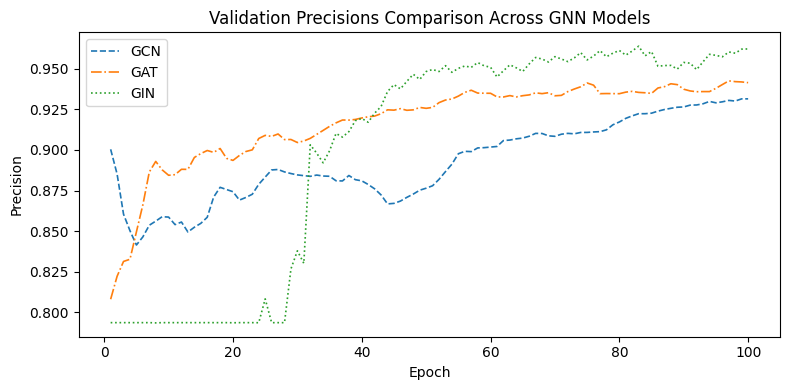

In [85]:
plt.figure(figsize=(8, 4))

epochs = range(1, len(metrics_per_gnn['gcn']['val']['precisions']) + 1)

plt.plot(epochs, metrics_per_gnn['gcn']['val']['precisions'], color='C0', linewidth=1.2, linestyle='--', label='GCN')
plt.plot(epochs, metrics_per_gnn['gat']['val']['precisions'], color='C1', linewidth=1.2, linestyle='-.', label='GAT')
plt.plot(epochs, metrics_per_gnn['gin']['val']['precisions'], color='C2', linewidth=1.2, linestyle=':', label='GIN')

plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Validation Precisions Comparison Across GNN Models')
plt.legend(fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()

__Conclusion:__

> GIN seems to perform the best overall in terms of precision, especially after stabilizing in the later epochs. It achieved the highest precision but showed initial instability.

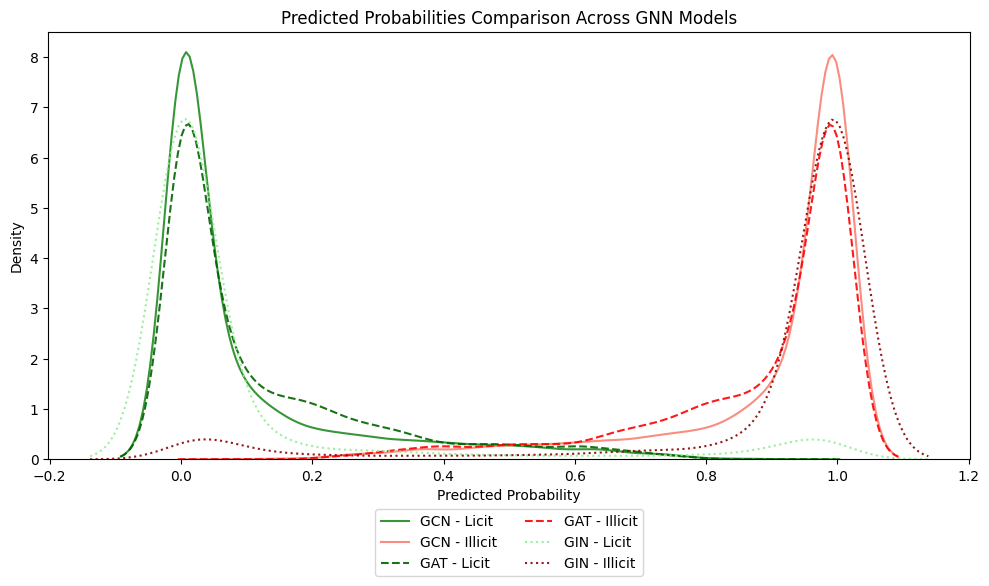

In [86]:
ALPHA = 0.9
FILL = False

plt.figure(figsize=(10, 6))

sns.kdeplot(metrics_per_gnn['gcn']['test']['licit']['probas'], fill=FILL, color="forestgreen", linestyle='-', alpha=ALPHA, label="GCN - Licit")
sns.kdeplot(metrics_per_gnn['gcn']['test']['illicit']['probas'], fill=FILL, color="salmon", linestyle='-', alpha=ALPHA, label="GCN - Illicit")

sns.kdeplot(metrics_per_gnn['gat']['test']['licit']['probas'], fill=FILL, color="darkgreen", linestyle='--', alpha=ALPHA, label="GAT - Licit")
sns.kdeplot(metrics_per_gnn['gat']['test']['illicit']['probas'], fill=FILL, color="red", linestyle='--', alpha=ALPHA, label="GAT - Illicit")

sns.kdeplot(metrics_per_gnn['gin']['test']['licit']['probas'], fill=FILL, color="lightgreen", linestyle=':', alpha=ALPHA, label="GIN - Licit")
sns.kdeplot(metrics_per_gnn['gin']['test']['illicit']['probas'], fill=FILL, color="darkred", linestyle=':', alpha=ALPHA, label="GIN - Illicit")

plt.title("Predicted Probabilities Comparison Across GNN Models")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()

plt.show()

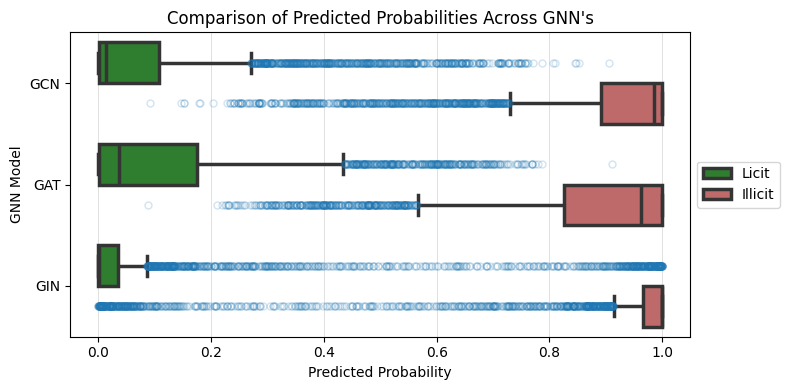

In [87]:
data_temp = []

for model in ['gcn', 'gat', 'gin']:
    for category in ['licit', 'illicit']:
        probas = metrics_per_gnn[model]['test'][category]['probas']
        data_temp.extend([(model.upper(), category.capitalize(), proba) for proba in probas])

temp = pd.DataFrame(data_temp, columns=['Model', 'Class', 'Probability'])

plt.figure(figsize=(8, 4))

flierprops = dict(marker='o', markerfacecolor='None', markersize=5,  markeredgecolor='C0', alpha=0.2)

ax = sns.boxplot(y='Model', x='Probability', hue='Class', data=temp,
                 linewidth=2.5,
                 fliersize=0.5,
                 palette={
                     'Licit': 'forestgreen',
                     'Illicit': 'indianred'
                 },
                 flierprops=flierprops
)


plt.grid(True, which='both', axis='x', color='lightgrey', linestyle='-', linewidth=0.5)
plt.title("Comparison of Predicted Probabilities Across GNN's")
plt.xlabel("Predicted Probability")
plt.ylabel("GNN Model")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), ncol=1)
plt.tight_layout()
plt.show()

In [88]:
# ------------------------------------------- #
# Running a t-test to compare the means of    #
# licit vs illicit predictions for each model #
# ------------------------------------------- #

comparisons = [('gcn', 'gat'), ('gcn', 'gin'), ('gat', 'gin')]
results = []

for model1, model2 in comparisons:
    for category in ['licit', 'illicit']:
        probas1 = metrics_per_gnn[model1]['test'][category]['probas']
        probas2 = metrics_per_gnn[model2]['test'][category]['probas']
        t_stat, p_val = ttest_ind(probas1, probas2, equal_var=False)
        if p_val < 0.05:
            results.append(f"Significant difference between {model1.upper()} and {model2.upper()} for {category.capitalize()} predictions (p-value: {p_val:.4f})")

for result in results:
    print(result)

Significant difference between GCN and GAT for Licit predictions (p-value: 0.0000)
Significant difference between GCN and GAT for Illicit predictions (p-value: 0.0000)
Significant difference between GAT and GIN for Licit predictions (p-value: 0.0006)
Significant difference between GAT and GIN for Illicit predictions (p-value: 0.0007)


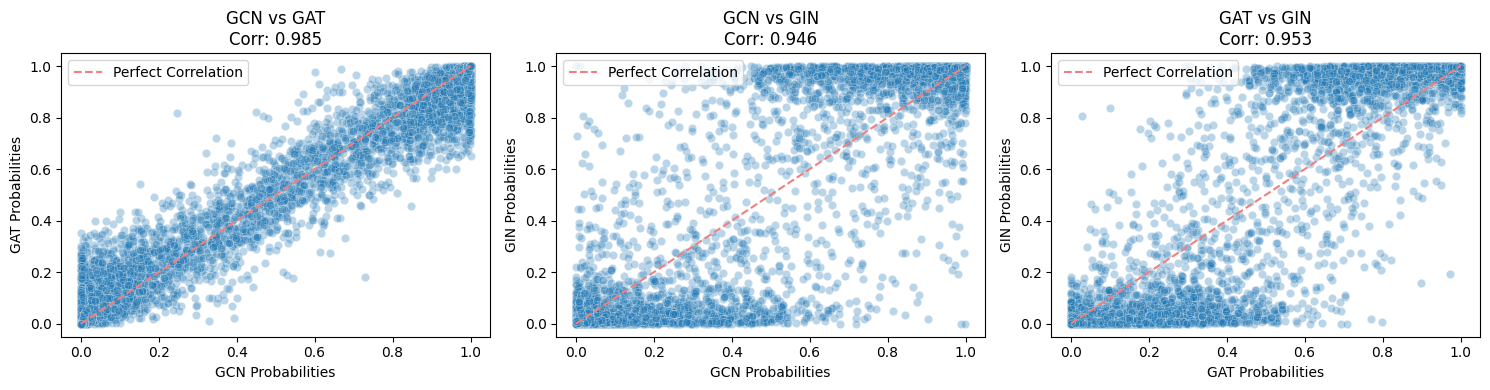

In [89]:
combinations = [('GCN', 'GAT'), ('GCN', 'GIN'), ('GAT', 'GIN')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model1, model2) in zip(axes, combinations):
    scatter_data = pd.DataFrame({
        f'{model1}_Probabilities': temp[temp['Model'] == model1]['Probability'].values,
        f'{model2}_Probabilities': temp[temp['Model'] == model2]['Probability'].values
    })

    sns.scatterplot(
        data=scatter_data,
        x=f'{model1}_Probabilities',
        y=f'{model2}_Probabilities',
        color='C0',
        edgecolor='white',
        marker='o',
        alpha=0.3, ax=ax
    )

    corr_value = np.corrcoef(temp[temp['Model'] == model1]['Probability'],
                             temp[temp['Model'] == model2]['Probability'])[0, 1]

    ax.plot([0, 1], [0, 1], ls='--', color='lightcoral', label=f'Perfect Correlation', alpha=1.0)

    ax.set_title(f'{model1} vs {model2}\nCorr: {corr_value:.3f}')
    ax.set_xlabel(f'{model1} Probabilities')
    ax.set_ylabel(f'{model2} Probabilities')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [90]:
# # --------------------- #
# # GPU-Accelerated t-SNE #
# # --------------------- #

# tsne = cuTSNE(n_components=2, random_state=RANDOM_STATE)#perplexity=10,
# embeddings_2d = tsne.fit_transform(embeddings)

# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=2, c=data.y.cpu().numpy(), cmap="jet", alpha=0.7)
# plt.colorbar(scatter, label='Class label')
# plt.title("GPU-accelerated t-SNE visualization of GIN node embeddings")
# plt.show()

In [91]:
# # ------------------------ #
# # Randomly subsample nodes #
# # ------------------------ #

# subset_size = 5_000

# embeddings = elliptic_txs_features.values

# indices = np.random.choice(len(embeddings), subset_size, replace=False)
# embeddings_subset = embeddings[indices]
# labels_subset = data.y.cpu().numpy()[indices]

# tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
# embeddings_2d = tsne.fit_transform(embeddings_subset)

# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=2, c=labels_subset, cmap="jet", alpha=0.7)
# plt.colorbar(scatter, label='Class label')
# plt.title("t-SNE visualization of GIN node embeddings (subsampled)")
# plt.show()

## Graph Explainability - `GNNExplainer` - TBD

The [GNN-Explainer](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.explain.algorithm.GNNExplainer.html#torch_geometric.explain.algorithm.GNNExplainer) model from the paper ["GNNExplainer: Generating Explanations for Graph Neural Networks"](https://arxiv.org/abs/1903.03894) can be used to identify compact subgraph structures and node features that play a crucial role the predictions made by the GNN.

In [103]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import (
    ExplanationType, ModelMode, MaskType, ModelReturnType
)

explainer = Explainer(
    model=gin_model,
    algorithm=GNNExplainer(epochs=100),
    explanation_type=ExplanationType.model,
    model_config=dict(
        mode=ModelMode.multiclass_classification,
        task_level='node',
        return_type=ModelReturnType.log_probs,
    ),
    node_mask_type=MaskType.attributes,
    edge_mask_type=MaskType.object
)


In [106]:
node_idx = 42  # Choose any node index you want to explain

explanation = explainer(
    x=data.x,
    edge_index=data.edge_index,
    index=node_idx,
    batch=data.batch
)


TypeError: GIN.forward() got an unexpected keyword argument 'batch'

# ToDos

- [x] Outsource the code used for each GNN into global methods. Will make the notebook shorter and more readable.
- [x] Train only on known nodes. Then validate on a small set of known nodes which was not trained on. Then predict on the unknown.
- [x] Implement GIN as well.
- [x] Compare all the models.
- [ ] Add short explanations for each GNN type + formulas.
- [ ] Develop a baseline model (non-GNN).
- [ ] Perform some graph explanability methods. for example GNNExplainer.
- [ ] Perform analysis on different sizes of node features and how they influence the performance.